## 1.0 Set up File

1.1 Import packages

In [7]:
import pandas as pd
from PIL import Image
import numpy as np
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf  # For tf.data
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.applications import EfficientNetB0
import scipy

In [8]:
tf.keras.backend.clear_session()

1.2 Define Model Parameters

In [9]:
IMG_SIZE = 224
BATCH_SIZE = 16

1.3 Read in Data

In [10]:
# Load dataframe
df = pd.read_csv("fossils_augmented.csv")

# Shuffle the dataframe for tensorflow training
df = df.sample(frac=1, random_state=10).reset_index(drop=True)

In [11]:
print(f"Total images: {len(df)}")
print(df["period"].value_counts())

Total images: 3611
period
Silurian Period         1024
Ordovician Period        337
Permian Period           250
Carboniferous Period     250
Jurassic Period          250
Cretaceous Period        250
Triassic Period          250
Cambrian Period          250
Precambrian Eon          250
Devonian Period          250
Cenozoic Era             250
Name: count, dtype: int64


1.4 Train/Test Split Data

In [12]:
# Split so no augmented images are in validation/test sets
train_df = df[df["augmented"] == True]
orig_df  = df[df["augmented"] == False]

# 80/20 split on originals only
val_df   = orig_df.sample(frac=0.2, random_state=42)
train_orig_df = orig_df.drop(val_df.index)

# Combine original training rows with augmented rows
train_df = pd.concat([train_orig_df, train_df], ignore_index=True).sample(frac=1, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 3144 | Val: 467


1.5 Run DataGenerators on Images

In [13]:
train_datagen = ImageDataGenerator()
val_datagen   = ImageDataGenerator()

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="local_path",
    y_col="period",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical", # one-hot encoding period labels
    shuffle=True,
    seed=1
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="local_path",
    y_col="period",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical", # one-hot encoding period labels
    shuffle=False
)

Found 3144 validated image filenames belonging to 11 classes.
Found 467 validated image filenames belonging to 11 classes.


1.6 Save Class Names and Batches

In [14]:
# Save class names for prediction later
import json
class_names = list(train_gen.class_indices.keys())
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print(f"\nClasses: {class_names}")
print(f"Training batches:   {len(train_gen)}")
print(f"Validation batches: {len(val_gen)}")


Classes: ['Cambrian Period', 'Carboniferous Period', 'Cenozoic Era', 'Cretaceous Period', 'Devonian Period', 'Jurassic Period', 'Ordovician Period', 'Permian Period', 'Precambrian Eon', 'Silurian Period', 'Triassic Period']
Training batches:   197
Validation batches: 30


## 2.0 Create Model

2.1 Define EfficientNetB0 Model

In [15]:
# Number of classes for final layer
NUM_CLASSES = len(class_names)

In [ ]:
# build model
base = EfficientNetB0(
    weights="imagenet",      # use pretrained weights
    include_top=False,       # remove ImageNet classification head
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False       # freeze base for phase 1

# add custom classification head
model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])


# HEAD ONLY TRAINING is for the dense, final output layers that are added on the frozen base
# BASE layers are those that extract features from images and are pretrained on ImageNet
# compile model for training
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3), # higher learning rate for head-only training
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 11)                2

2.2 Head Only Training

In [10]:
# Train the head layers first with the base frozen to get a good starting point for the final layers
hist1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10, # number of forward/backward passes on the whole dataset, can be adjusted based on convergence
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

Epoch 1/10
197/197 [==============================] - 84s 288ms/step - loss: 1.8182 - accuracy: 0.4539 - val_loss: 1.2972 - val_accuracy: 0.5503
Epoch 2/10
197/197 [==============================] - 9s 46ms/step - loss: 1.0683 - accuracy: 0.6482 - val_loss: 1.1190 - val_accuracy: 0.6060
Epoch 3/10
197/197 [==============================] - 7s 36ms/step - loss: 0.8163 - accuracy: 0.7166 - val_loss: 1.1654 - val_accuracy: 0.5910
Epoch 4/10
197/197 [==============================] - 7s 35ms/step - loss: 0.6689 - accuracy: 0.7675 - val_loss: 1.1108 - val_accuracy: 0.6381
Epoch 5/10
197/197 [==============================] - 8s 42ms/step - loss: 0.5793 - accuracy: 0.7987 - val_loss: 1.0054 - val_accuracy: 0.6552
Epoch 6/10
197/197 [==============================] - 9s 44ms/step - loss: 0.5050 - accuracy: 0.8257 - val_loss: 1.0882 - val_accuracy: 0.6531
Epoch 7/10
197/197 [==============================] - 8s 40ms/step - loss: 0.4417 - accuracy: 0.8499 - val_loss: 1.0583 - val_accuracy: 0.66

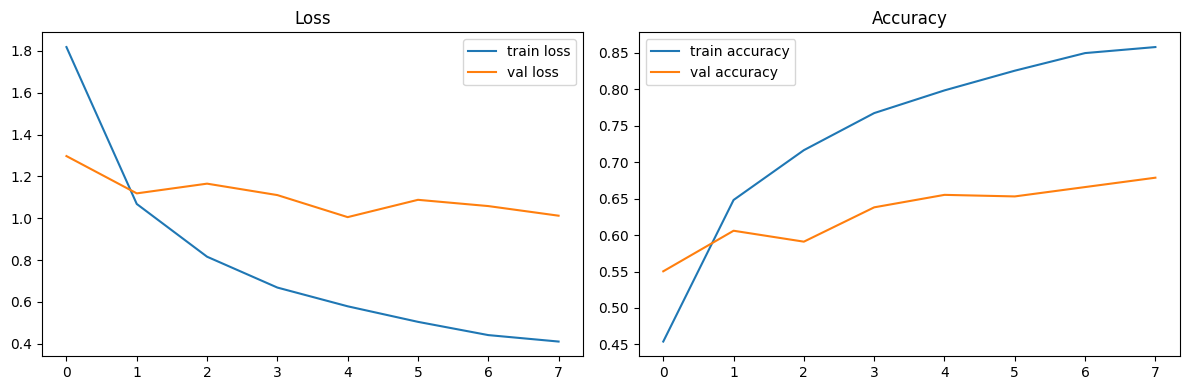

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist1.history["loss"], label="train loss")
axes[0].plot(hist1.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist1.history["accuracy"], label="train accuracy")
axes[1].plot(hist1.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

2.3 Unfreeze Base, Whole Model Training

In [13]:
# UNFREEZE BASE for fine-tuning with a much lower learning rate to avoid destroying pretrained weights
base.trainable = True

# Recompile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # lower learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Fine-tune the whole model with a lower learning rate and more epochs, using callbacks to prevent overfitting
hist2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30, # number of forward/backward passes on the whole dataset, can be adjusted based on convergence
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.2)
    ]
)

# Save just the weights
model.save_weights("fossil_model_weights.h5")

# Save the class names too
import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

Epoch 1/30


197/197 [==============================] - 55s 176ms/step - loss: 0.3130 - accuracy: 0.8909 - val_loss: 0.9983 - val_accuracy: 0.6788 - lr: 1.0000e-05
Epoch 2/30
197/197 [==============================] - 32s 162ms/step - loss: 0.2766 - accuracy: 0.9087 - val_loss: 0.9875 - val_accuracy: 0.6681 - lr: 1.0000e-05
Epoch 3/30
197/197 [==============================] - 29s 146ms/step - loss: 0.3003 - accuracy: 0.9030 - val_loss: 0.9945 - val_accuracy: 0.6767 - lr: 1.0000e-05
Epoch 4/30
197/197 [==============================] - 28s 141ms/step - loss: 0.2713 - accuracy: 0.9071 - val_loss: 0.9881 - val_accuracy: 0.6831 - lr: 1.0000e-05
Epoch 5/30
197/197 [==============================] - 30s 154ms/step - loss: 0.2623 - accuracy: 0.9167 - val_loss: 0.9807 - val_accuracy: 0.6788 - lr: 1.0000e-05
Epoch 6/30
197/197 [==============================] - 31s 155ms/step - loss: 0.2488 - accuracy: 0.9208 - val_loss: 0.9796 - val_accuracy: 0.6852 - lr: 1.0000e-05
Epoch 7/30
197/197 [===================

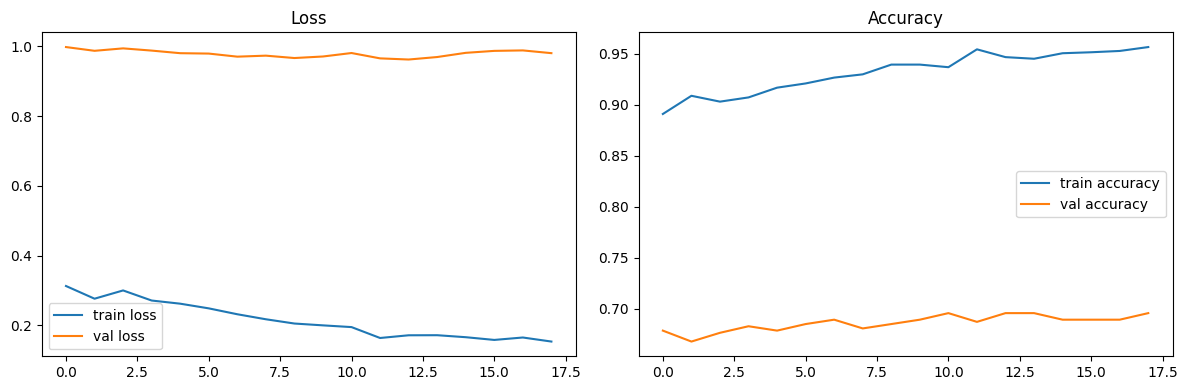

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist2.history["loss"], label="train loss")
axes[0].plot(hist2.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist2.history["accuracy"], label="train accuracy")
axes[1].plot(hist2.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

2.4 Checking Class Accuracy

30/30 [==============================] - 8s 215ms/step
                      precision    recall  f1-score   support

     Cambrian Period       0.67      1.00      0.80         4
Carboniferous Period       0.76      0.58      0.66        45
        Cenozoic Era       0.83      0.71      0.76        34
   Cretaceous Period       0.75      0.86      0.80        14
     Devonian Period       0.58      0.45      0.51        49
     Jurassic Period       0.64      0.78      0.70        18
   Ordovician Period       0.67      0.55      0.60        77
      Permian Period       1.00      1.00      1.00         4
     Precambrian Eon       0.67      0.88      0.76        16
     Silurian Period       0.70      0.79      0.74       203
     Triassic Period       0.60      1.00      0.75         3

            accuracy                           0.70       467
           macro avg       0.71      0.78      0.73       467
        weighted avg       0.70      0.70      0.69       467



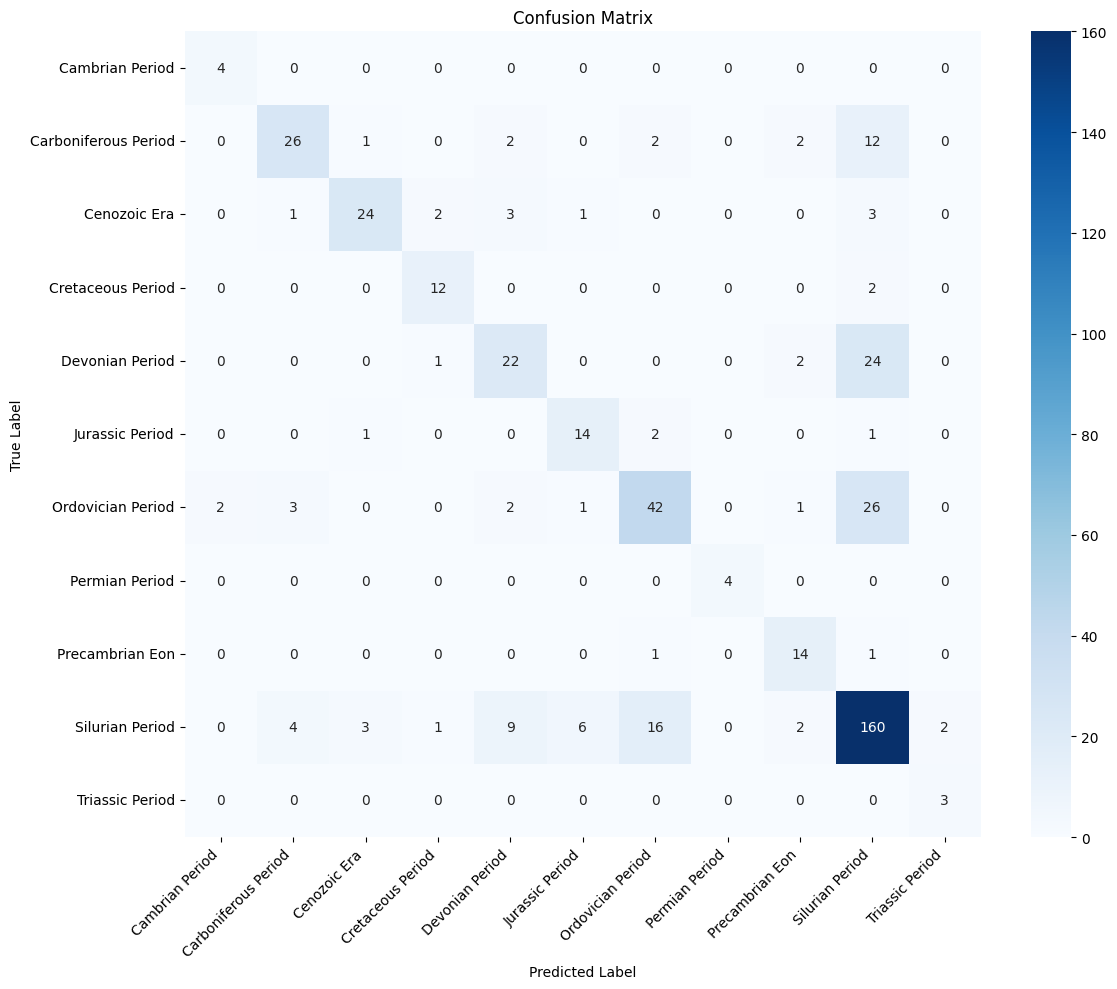

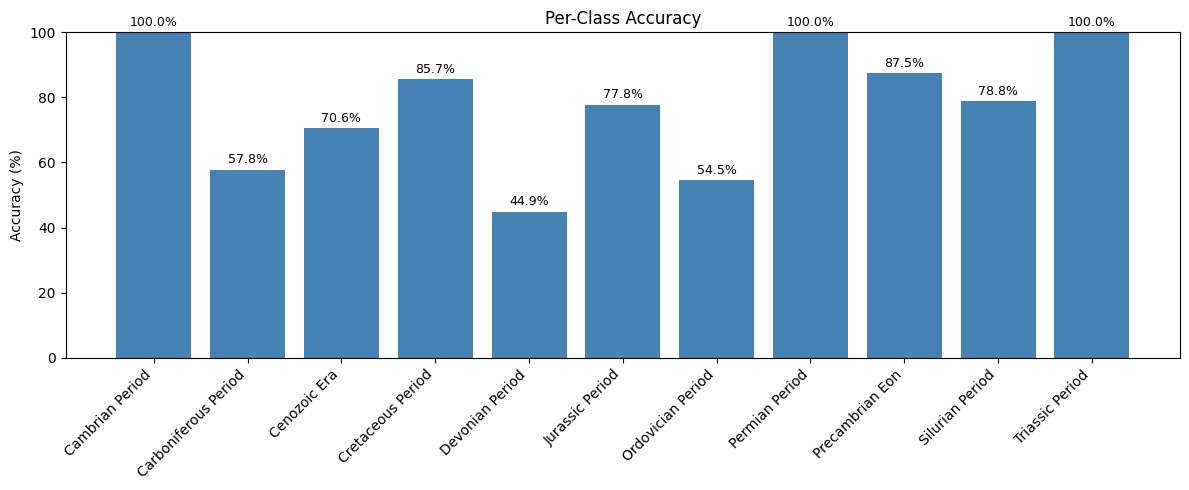

In [39]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions on validation set
# Reset generator to start from beginning
val_gen.reset()

y_pred = model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes  # true labels as integers

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Per class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, per_class_acc * 100, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy")
plt.ylim(0, 100)

# Add value labels on top of each bar
for bar, acc in zip(bars, per_class_acc):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{acc*100:.1f}%",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

## 3.0 Predicting on Our Own Images

3.1 Reload Model

In [17]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import numpy as np
from tensorflow.keras.preprocessing import image

# Rebuild model in the same way
base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Load weights back in
model.load_weights("fossil_model_weights.h5")

# Load class names
with open("class_names.json") as f:
    class_names = json.load(f)

3.2 Create Prediction Function

In [24]:
## REMAKE PREPROCESSING FUNCTIONS FOR PREDICTION
# Cropping function: find bounding box of non-background pixels and crop, with optional padding
def crop_to_fossil(img, threshold=30, padding=10):
    arr = np.array(img)
    mask = arr.max(axis=2) > threshold
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    h, w = arr.shape[:2]
    rmin = max(0, rmin - padding)
    rmax = min(h, rmax + padding)
    cmin = max(0, cmin - padding)
    cmax = min(w, cmax + padding)
    return img.crop((cmin, rmin, cmax, rmax))

# Padding function: pad the cropped image to a square shape, centered, with a specified fill color
def pad_to_square(img, fill=(0, 0, 0)):
    w, h = img.size
    size = max(w, h)  # square size based on longest side
    # Create a black square canvas and paste the image centered
    square = Image.new("RGB", (size, size), fill)
    offset = ((size - w) // 2, (size - h) // 2)
    square.paste(img, offset)
    return square


# Predict function for single images
def predict_fossil(model, img_path, class_names, img_size=224):
    # Same preprocessing pipeline as training
    img = Image.open(img_path).convert("RGB")
    img = crop_to_fossil(img)
    img = pad_to_square(img)
    img = img.resize((img_size, img_size), Image.LANCZOS)

    # Convert to array and add batch dimension
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)  # (224, 224, 3) → (1, 224, 224, 3)

    # Run model
    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    # Show image with prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.1f}%")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # Top 3 predictions
    top3 = np.argsort(predictions[0])[::-1][:3]
    print("Top 3 predictions:")
    for i in top3:
        print(f"  {class_names[i]}: {predictions[0][i]*100:.1f}%")

    return predicted_class, confidence

3.3 Test New Images

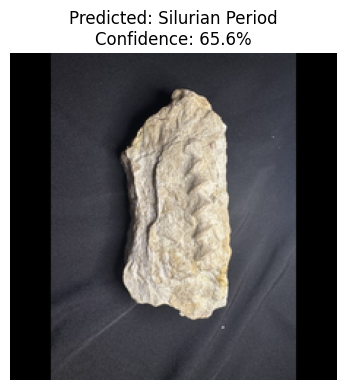

Top 3 predictions:
  Silurian Period: 65.6%
  Cenozoic Era: 18.1%
  Carboniferous Period: 13.8%


('Silurian Period', 65.55628180503845)

In [26]:
predict_fossil(model, "../Data/personal images/archimedes carboniferous_permian.jpeg", class_names)

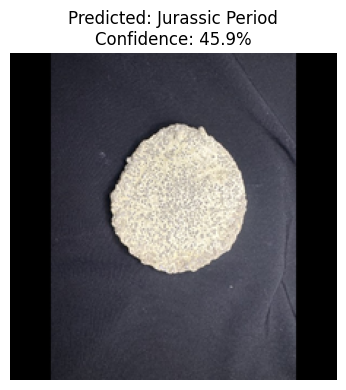

Top 3 predictions:
  Jurassic Period: 45.9%
  Silurian Period: 31.3%
  Ordovician Period: 20.5%


('Jurassic Period', 45.87419331073761)

In [27]:
predict_fossil(model, "../Data/personal images/astraeospongia_silurian.jpeg", class_names)

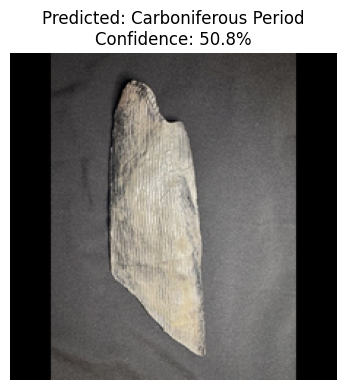

Top 3 predictions:
  Carboniferous Period: 50.8%
  Silurian Period: 31.6%
  Cenozoic Era: 16.3%


('Carboniferous Period', 50.82595348358154)

In [28]:
predict_fossil(model, "../Data/personal images/calymite_carboniferous.jpeg", class_names)

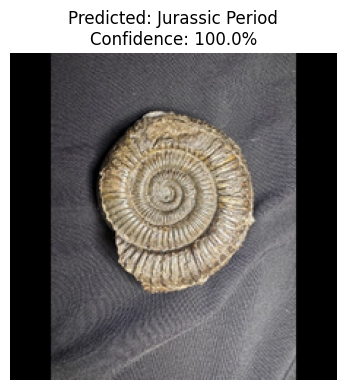

Top 3 predictions:
  Jurassic Period: 100.0%
  Silurian Period: 0.0%
  Cenozoic Era: 0.0%


('Jurassic Period', 99.95272159576416)

In [29]:
predict_fossil(model, "../Data/personal images/dactylioceras_jurassic.jpeg", class_names)

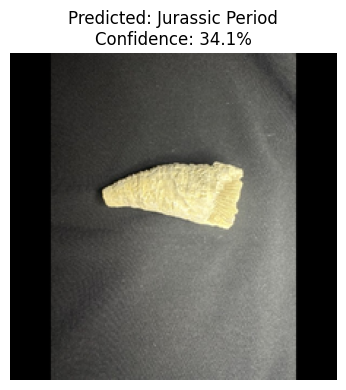

Top 3 predictions:
  Jurassic Period: 34.1%
  Ordovician Period: 29.4%
  Silurian Period: 27.3%


('Jurassic Period', 34.1251403093338)

In [30]:
predict_fossil(model, "../Data/personal images/horned coral_ordovician.jpeg", class_names)